In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Prep

In [3]:
transect = pd.read_csv('../../../data/Transect.csv')
ssdf = pd.read_csv('../../../data/SCDsSomerset.csv')

# Overall Stats:

In [15]:
transect['mean'] = transect[['Res 1', 'Res 2', 'Res 3 ', 'Res 4']].mean(axis=1)

In [21]:
sampled_sites = len(transect) + len(ssdf)
print(f'Total sampled sites: {sampled_sites}')
print(len(transect), 'transect sites')

Total sampled sites: 49
34 transect sites


In [20]:
transect_median = transect['mean'].median(axis=0)
print(f'Transect median: {transect_median}')

Transect median: 4.75


Localities above background:

In [81]:
background_level = 9
print(f'Localities above background: {len(ssdf[ssdf["Average"] > background_level]) + len(transect[transect[["Res 1", "Res 2", "Res 3 ", "Res 4"]].mean(axis=1) > background_level])}')

Localities above background: 15


# Background Threshold

## Using Mean

In [29]:
# median absolute deviation
# calculating background level using median absolute deviation (MAD)

mad = (df['mean'] - df['mean'].median()).abs().median()
print(f'Median Absolute Deviation: {mad}')

median = df['mean'].median()
print(f'Median: {median}')

background_level = median + 2 * mad
print(f'Background Level: {background_level}')


Median Absolute Deviation: 2.25
Median: 4.5
Background Level: 9.0


## Using max

In [32]:
# median absolute deviation
# calculating background level using median absolute deviation (MAD)

mad = (df['H2Max'] - df['H2Max'].median()).abs().median()
print(f'Median Absolute Deviation: {mad}')

median = df['H2Max'].median()
print(f'Median: {median}')

max_background_level = median + 2 * mad
print(f'Background Level: {max_background_level}')

Median Absolute Deviation: 4.5
Median: 8.5
Background Level: 17.5


# SCDs above background

## Using Mean

In [45]:
ssdf = pd.read_csv('../../../data/SCDsSomerset.csv')
ssdf['log_mean'] = np.log10(ssdf['Average'])
ssdf['log_max'] = np.log10(ssdf['Max'])

In [ ]:
print(f'Num SCDs above background level: {ssdf[ssdf["Average"] > 4.5].shape[0]}')

Num SCDs above background level: 5


# Max and Mean population histograms

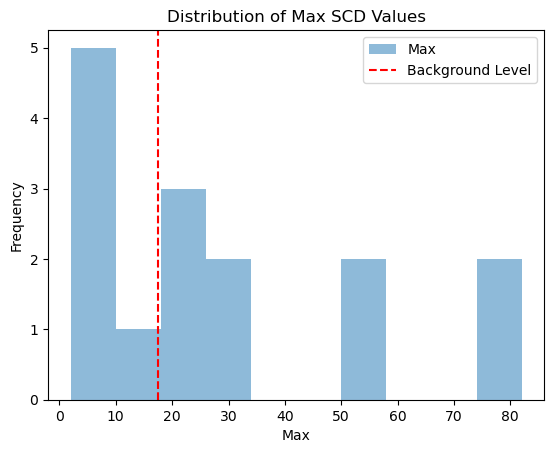

In [67]:
plt.hist(ssdf['Max'], bins=10, alpha=0.5, label='Max')
plt.axvline(max_background_level, color='r', linestyle='dashed',  label='Background Level')   
plt.xlabel('Max')
plt.ylabel('Frequency')
plt.title('Distribution of Max SCD Values')
plt.legend()
plt.show()

# SCD vs Non-SCD populations

Yes: n=15, median=7.769, mean=11.638
No:  n=33, median=4.750, mean=7.182

Mann-Whitney U: U=300.0, p=0.2472
Welch's t-test: t=1.522, p=0.1452


/var/folders/fx/yls4l5xd4cdgs4b7gy2xpdv40000gn/T/ipykernel_6980/2018207579.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([no_vals, yes_vals], labels=['No', 'Yes'])


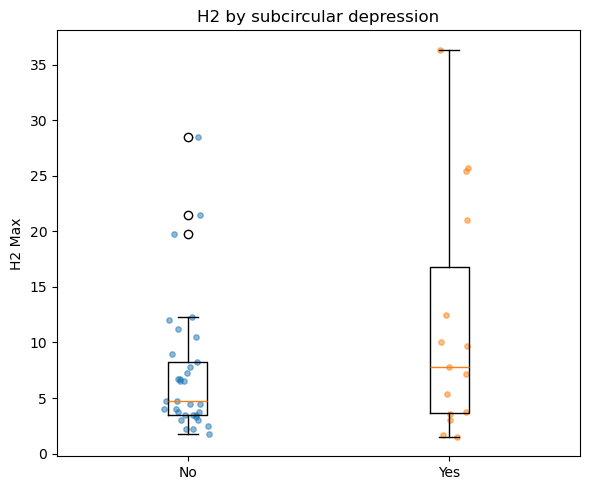

In [79]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

cols = ['Res 1', 'Res 2', 'Res 3 ', 'Res 4']
yes_vals = ssdf['Average']
no_vals = pd.read_csv('../../../data/Transect.csv')[cols].mean(axis=1)

no_vals = no_vals[no_vals < 100]
print(f"Yes: n={len(yes_vals)}, median={yes_vals.median():.3f}, mean={yes_vals.mean():.3f}")
print(f"No:  n={len(no_vals)}, median={no_vals.median():.3f}, mean={no_vals.mean():.3f}")

u_stat, u_p = stats.mannwhitneyu(yes_vals, no_vals, alternative='two-sided')
t_stat, t_p = stats.ttest_ind(yes_vals, no_vals, equal_var=False)

print(f"\nMann-Whitney U: U={u_stat:.1f}, p={u_p:.4f}")
print(f"Welch's t-test: t={t_stat:.3f}, p={t_p:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot([no_vals, yes_vals], labels=['No', 'Yes'])
ax.scatter(np.random.normal(1, 0.04, len(no_vals)), no_vals, alpha=0.5, s=15)
ax.scatter(np.random.normal(2, 0.04, len(yes_vals)), yes_vals, alpha=0.5, s=15)
ax.set_ylabel('H2 Max')
ax.set_title('H2 by subcircular depression')
plt.tight_layout()
plt.show()

In [60]:
from scipy import stats

u_stat, _ = stats.mannwhitneyu(yes_vals, no_vals, alternative='two-sided')
n1, n2 = len(yes_vals), len(no_vals)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)
print(f"Rank-biserial correlation: {rank_biserial:.3f}")

# back-transformed medians, actual units
print(f"Yes median (actual): {yes_vals.median():.2f}")
print(f"No median (actual):  {no_vals.median():.2f}")

Rank-biserial correlation: -0.386
Yes median (actual): 23.00
No median (actual):  10.00
